In [ ]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")
# cfe.logger.setLevel("DEBUG")

[2025年04月07日 19时51分18秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
start_id = "Run5_164698952452459"
terminal_states = ["Run5_131097901611291", "Run5_134936662236454", "Run4_200562869397916"]
save_cell_list = [start_id] + terminal_states

fadata = cfe.data.read_bonemarrow(n_obs=500, save_cell_list=save_cell_list) 
fadata

                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      
                        DEBUG    FateAnnData add_trajectory                                                        


AnnData object with n_obs × n_vars = 500 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    uns: 'cfe'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

                        DEBUG    plot_trajectory                                                                   
[2025年04月07日 19时51分19秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
                        DEBUG    add waypoints shape is (214, 500), finished!                                      
[2025年04月07日 19时51分20秒] DEBUG    plot_trajectory                                                             
                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年04月07日 19时51分21秒] DEBUG    add waypoints shape is (214, 500), finished!                                


AnnData object with n_obs × n_vars = 500 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'milestone_color', 'milestone'
    uns: 'cfe', 'milestone_color_dict', 'milestone_colors', 'milestone_color_colors'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

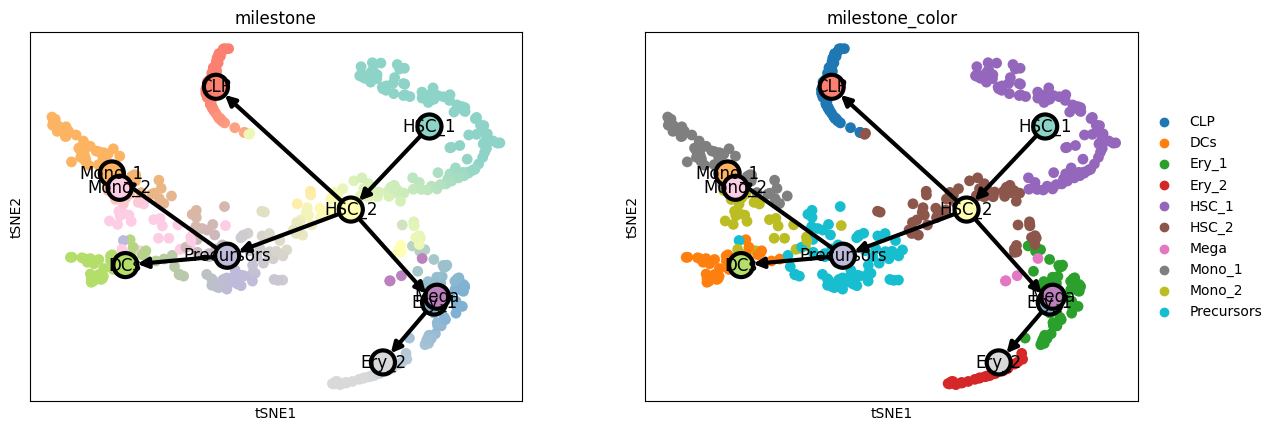

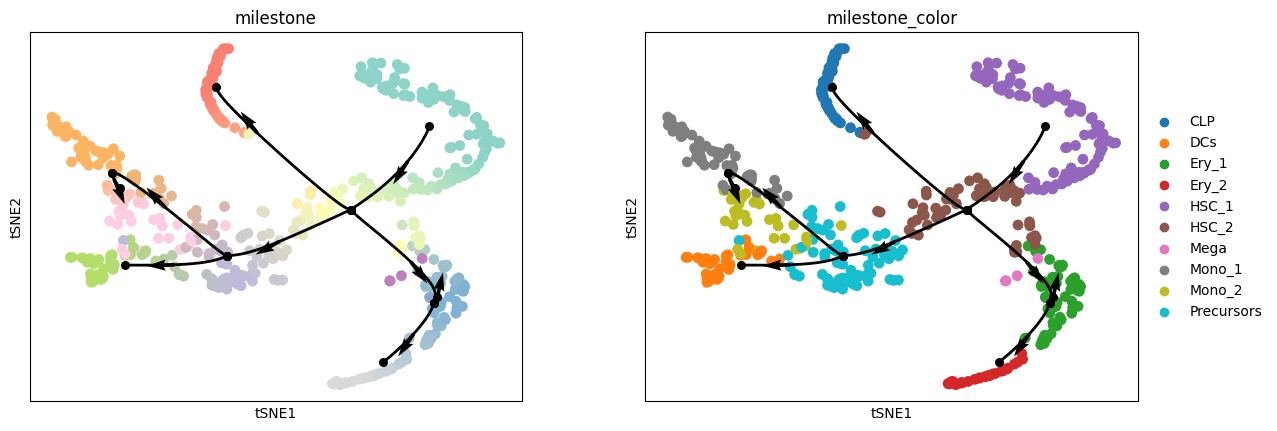

In [3]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "tsne"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=False)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=True)
fadata

[2025年04月07日 19时51分23秒] INFO     find wrapper type: directed                                                 


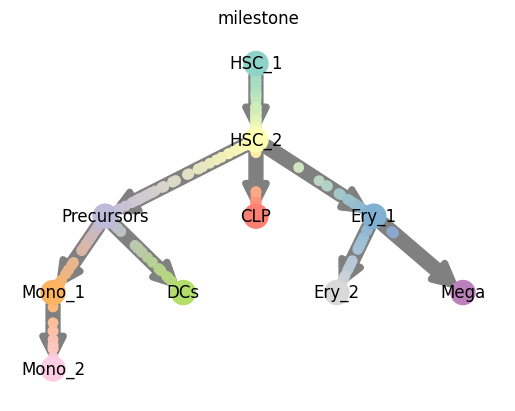

In [4]:
cfe.plot.plot_wrapper(fadata)

[2025年04月07日 19时51分26秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_palantir at 0x7ebf5735a9e0> from                    
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 palantir.py                                                                       
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x7ec0082831c0>                                                                   
repreprocess
Sampling and flocking waypoints...
Time for determining waypoints: 0.0008432507514953613 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.16981000502904256 minutes
Iteratively refining the pseudotime...
Correlation at iteratio

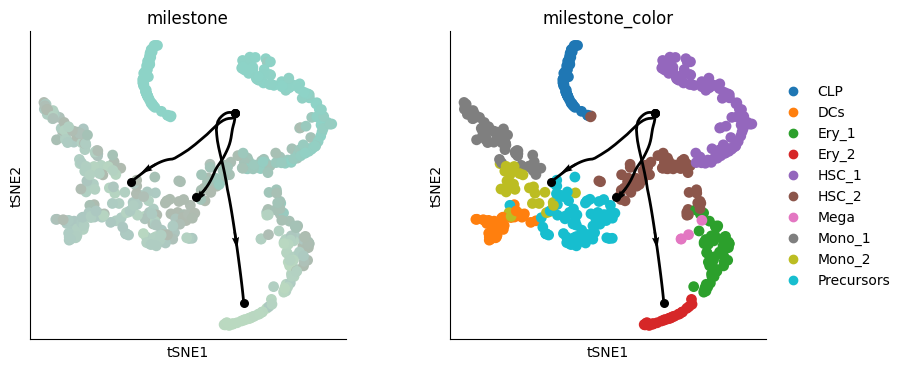

In [5]:
prior_information = {
    "start_id": start_id,
    "terminal_states": terminal_states,
}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
parameters = {"wrapper_type": "probability", "linear_type": "pseudotime"} # add parameters when inferring trajectory


method_name_list = ["palantir"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

In [6]:
# 查看里程碑
trajectory_history_dict = fadata.uns["cfe"]["trajectory_history_dict"]
for k in trajectory_history_dict.keys():
    if "palantir" in k:
        print(trajectory_history_dict[k]["milestone_wrapper"]["id_list"])

['milestone_begin', 'Run4_200562869397916', 'Run5_131097901611291', 'Run5_134936662236454']
